In [11]:
import pandas as pd
import numpy as np
import joblib
import math
import matplotlib.pyplot as plt
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler

In [12]:
import random
random.seed(42)

In [13]:
features = ['cpu', 'ram', 'rps']
TARGET_FEATURE = 'cpu' # 🎯 Наша єдина ціль для автоскейлера
WINDOW_SIZE = 10
FORECAST_HORIZON = 4 

# Завантажуємо твої файли
df_main = pd.read_csv("./clean_data/train_data_2.csv") 
df_ext = pd.read_csv("./clean_data/training_data.csv") 

def transform_to_log_returns(df, cols, target_col, horizon):
    """
    Магія фінансової математики: Перетворюємо абсолютні значення 
    у логарифмічні зміни (Log Returns). 
    Модель більше не відволікатиметься на прогнозування RAM та RPS.
    """
    df_log = pd.DataFrame()
    epsilon = 1e-6 # Захист від ділення на нуль
    
    # 1. X: Формуємо історію кроків для ВСІХ фічей (CPU, RAM, RPS)
    for f in cols:
        df_log[f'{f}_step'] = np.log((df[f] + epsilon) / (df[f].shift(1) + epsilon))
        
    # 2. Y: Формуємо майбутню ціль ТІЛЬКИ для процесора
    future_peak = df[target_col].rolling(window=horizon).max().shift(-horizon)
    df_log[f'{target_col}_target'] = np.log((future_peak + epsilon) / (df[target_col] + epsilon))
        
    return df_log.dropna()

print("🔄 Перетворення даних у Log Returns (Фокус виключно на CPU)...")
df_main_log = transform_to_log_returns(df_main, features, TARGET_FEATURE, FORECAST_HORIZON)
df_ext_log = transform_to_log_returns(df_ext, features, TARGET_FEATURE, FORECAST_HORIZON)

# Дані тепер мають 4 колонки: перші 3 — це ознаки (X), остання 1 — це ціль (y)
data_main_raw = df_main_log.values
data_ext_raw = df_ext_log.values

print(f"✅ Готово! Форма головного датасету: {data_main_raw.shape} (3 фічі + 1 таргет)")

🔄 Перетворення даних у Log Returns (Фокус виключно на CPU)...
✅ Готово! Форма головного датасету: (2154, 4) (3 фічі + 1 таргет)


In [14]:
def create_sequences(X_data, y_data, window_size=10):
    """Створює вікна для нейромережі з уже розділених X та y"""
    X, y = [], []
    for i in range(len(X_data) - window_size + 1):
        X.append(X_data[i : i + window_size])
        # Цілі (y) вже зсунуті в майбутнє на етапі Pandas, тому беремо кінець вікна
        y.append(y_data[i + window_size - 1])
    return np.array(X), np.array(y)

# ==========================================
# 2. ПРОСТІР ПОШУКУ АРХІТЕКТУРИ (СНАЙПЕРСЬКА ВЕРСІЯ)
# ==========================================
def build_model(hp):
    model = Sequential()
    # На вхід все ще йдуть 3 фічі (CPU, RAM, RPS)
    model.add(Input(shape=(WINDOW_SIZE, len(features)))) 
    
    model_type = hp.Choice('model_type', values=['lstm', 'gru', 'cnn'])
    
    layer_size = hp.Int('layer_size', 32, 128, 32)
    
    if model_type == 'lstm':
        model.add(LSTM(units=layer_size))
    elif model_type == 'gru':
        model.add(GRU(units=layer_size))
    elif model_type == 'cnn':
        model.add(Conv1D(filters=layer_size, kernel_size=3, activation='relu'))
        model.add(GlobalMaxPooling1D())
        
    model.add(Dropout(hp.Float('dropout', 0.1, 0.4, 0.1)))
    
    # 💡 МАГІЯ ТУТ: Вихідний шар тепер має лише 1 нейрон (ціль - тільки CPU)
    model.add(Dense(1)) 
    
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3])
    
    # 💡 ЗМІНА: Використовуємо MAE для стійкості до аномальних стрибків трафіку
    model.compile(optimizer=Adam(learning_rate=hp_lr), loss='mae', metrics=['mae'])
    
    return model

# ==========================================
# 3. КАСТОМНИЙ ТЮНЕР (ФОКУС НА ОДНІЙ ЦІЛІ)
# ==========================================
class AcademicCVTuner(kt.RandomSearch):
    def run_trial(self, trial, raw_data, **fit_kwargs):
        tscv = TimeSeriesSplit(n_splits=5)
        val_losses = []
        stopped_epochs = []
        
        batch_size = trial.hyperparameters.Choice('batch_size', values=[16, 32, 64])
        initial_lr = trial.hyperparameters.get('learning_rate')
        
        def local_cosine(epoch, lr):
            return (initial_lr - 1e-5) * 0.5 * (1 + math.cos(math.pi * epoch / 30)) + 1e-5
        cosine_cb = LearningRateScheduler(local_cosine, verbose=0)
        
        print(f"\n⚙️ Спроба {trial.trial_id} | Модель: {trial.hyperparameters.get('model_type').upper()} | Batch: {batch_size}")
        
        fold = 1
        for train_idx, val_idx in tscv.split(raw_data):
            train_fold, val_fold = raw_data[train_idx], raw_data[val_idx]
            
            # 💡 ЗМІНА: Колонки 0,1,2 - це X (вхід), а колонка 3 - це y (таргет CPU)
            # Використовуємо слайс [:, 3:4], щоб масив y лишився 2D для StandardScaler
            train_X_raw, train_y_raw = train_fold[:, :3], train_fold[:, 3:4]
            val_X_raw, val_y_raw = val_fold[:, :3], val_fold[:, 3:4]
            
            # СТВОРЮЄМО ОКРЕМІ СКЕЙЛЕРИ ДЛЯ X ТА Y
            fold_scaler_X = StandardScaler()
            fold_scaler_y = StandardScaler()
            
            train_X_scaled = fold_scaler_X.fit_transform(train_X_raw)
            train_y_scaled = fold_scaler_y.fit_transform(train_y_raw)
            
            val_X_scaled = fold_scaler_X.transform(val_X_raw)
            val_y_scaled = fold_scaler_y.transform(val_y_raw)
            
            # Нарізаємо вікна
            X_train, y_train = create_sequences(train_X_scaled, train_y_scaled, WINDOW_SIZE)
            X_val, y_val = create_sequences(val_X_scaled, val_y_scaled, WINDOW_SIZE)
            
            model = self.hypermodel.build(trial.hyperparameters)
            fold_early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
            
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                batch_size=batch_size, epochs=30,
                callbacks=[fold_early_stop, cosine_cb], verbose=0
            )
            
            val_loss = min(history.history['val_loss'])
            val_losses.append(val_loss)
            
            actual_epochs = fold_early_stop.stopped_epoch if fold_early_stop.stopped_epoch > 0 else 30
            stopped_epochs.append(actual_epochs)
            
            # Змінили логи з MSE на MAE
            print(f"  └ Фолд {fold} MAE: {val_loss:.5f} (Епох: {actual_epochs})")
            fold += 1
            
        avg_val_loss = np.mean(val_losses)
        trial.metrics.update('val_loss', avg_val_loss)
        trial.metrics.update('optimal_epochs', np.mean(stopped_epochs))
        
        print(f"📊 Середній MAE: {avg_val_loss:.5f} | Сер. епох: {int(np.mean(stopped_epochs))}")
        return avg_val_loss

In [15]:
# ==========================================
# 4. ЗАПУСК ПОШУКУ (GRID SEARCH)
# ==========================================
print("\n🚀 РОЗПОЧИНАЄМО ПОВНИЙ ПЕРЕБІР (GridSearch)")
tuner = AcademicCVTuner(
    hypermodel=build_model,
    objective='val_loss',
    directory='k8s_tuning_one_feature',
    project_name='final_autoscaler',
    max_trials=12,
    overwrite=True # <--- FALSE! Це дозволить продовжити перерване навчання
)

tuner.search(raw_data=data_main_raw)

Trial 12 Complete [00h 00m 05s]
val_loss: 0.4044111788272858

Best val_loss So Far: 0.20114107802510262
Total elapsed time: 00h 02m 12s


In [16]:
# ==========================================
# 4.1. ПОРІВНЯЛЬНА ТАБЛИЦЯ НАЙКРАЩИХ АРХІТЕКТУР
# ==========================================
print("\n" + "="*65)
print("🏆 ПІДСУМКОВА ТАБЛИЦЯ НАЙКРАЩИХ РЕЗУЛЬТАТІВ КРОС-ВАЛІДАЦІЇ")
print("="*65)
print(f"{'Модель':<8} | {'MSE (CV)':<10} | {'Епох':<6} | {'Нейрони/Фільтри':<16} | {'Batch':<6} | {'Dropout':<7}")
print("-" * 65)

best_by_type = {}
for trial in tuner.oracle.trials.values():
    m_type = trial.hyperparameters.get('model_type')
    score = trial.score
    if score is not None:
        if m_type not in best_by_type or score < best_by_type[m_type]['score']:
            best_by_type[m_type] = {
                'score': score,
                'hps': trial.hyperparameters,
                'epochs': trial.metrics.get_best_value('optimal_epochs')
            }

sorted_best = sorted(best_by_type.items(), key=lambda item: item[1]['score'])

for m_type, data in sorted_best:
    hps = data['hps']
    score = data['score']
    epochs = int(data['epochs']) if data['epochs'] else 30
    
    # 💡 ВИПРАВЛЕНО ТУТ: Просто беремо нашу єдину універсальну змінну
    units = hps.get('layer_size')
        
    batch = hps.get('batch_size')
    dropout = hps.get('dropout')
    print(f"{m_type.upper():<8} | {score:<10.5f} | {epochs:<6} | {units:<16} | {batch:<6} | {dropout:<7.1f}")
print("="*65)


🏆 ПІДСУМКОВА ТАБЛИЦЯ НАЙКРАЩИХ РЕЗУЛЬТАТІВ КРОС-ВАЛІДАЦІЇ
Модель   | MSE (CV)   | Епох   | Нейрони/Фільтри  | Batch  | Dropout
-----------------------------------------------------------------
GRU      | 0.20114    | 11     | 32               | 64     | 0.4    
LSTM     | 0.20582    | 8      | 128              | 32     | 0.3    
CNN      | 0.39760    | 10     | 128              | 16     | 0.2    



📈 Генеруємо криві навчання (Хронологічно чистий спліт, Фокус на CPU)...


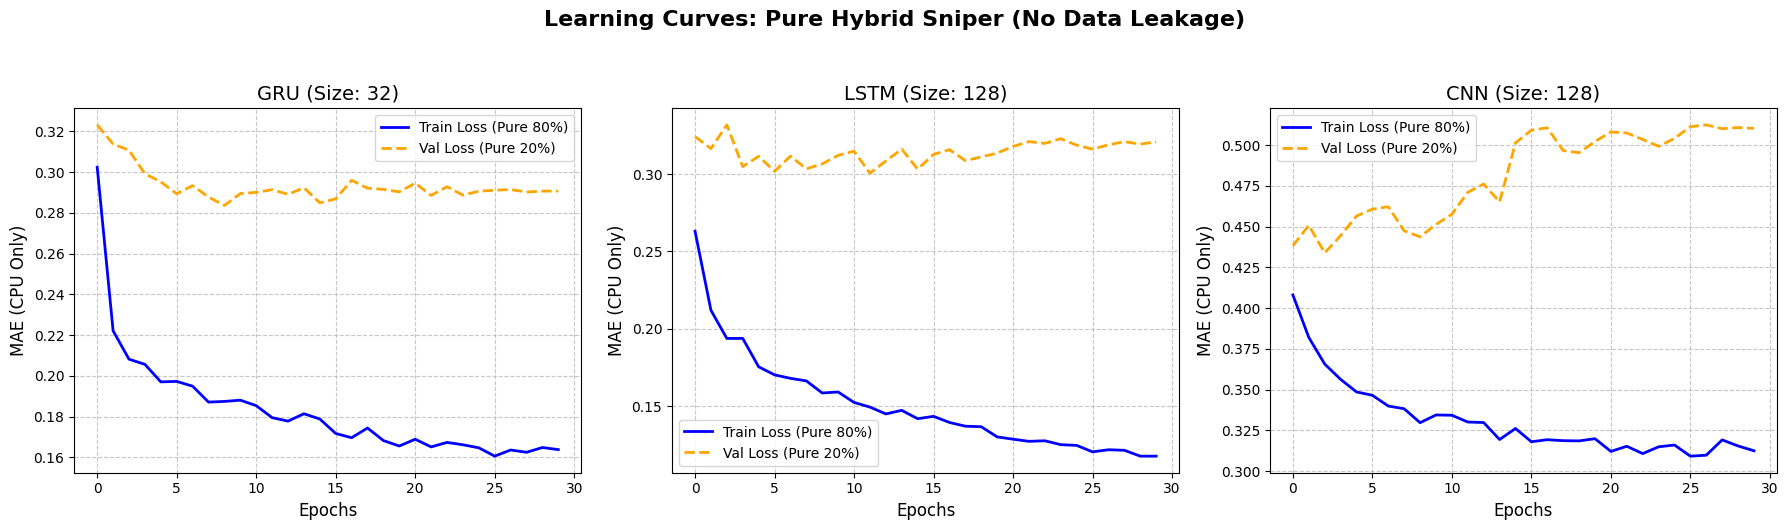

In [17]:
# ==========================================
# 5. ГЕНЕРАЦІЯ ГРАФІКІВ (Академічно чистий Гібридний Снайпер)
# ==========================================
print("\n📈 Генеруємо криві навчання (Хронологічно чистий спліт, Фокус на CPU)...")

# 1. Хронологічний спліт (80/20) ДЛЯ КОЖНОГО датасету окремо ПЕРЕД змішуванням
split_main = int(len(data_main_raw) * 0.8)
split_ext = int(len(data_ext_raw) * 0.8)

train_main_raw = data_main_raw[:split_main]
val_main_raw = data_main_raw[split_main:]

train_ext_raw = data_ext_raw[:split_ext]
val_ext_raw = data_ext_raw[split_ext:]

# 2. Об'єднуємо Train з Train, Val з Val
# Тепер Train має і нормальні дані, і Locust, але хронологія всередині шматків збережена
train_combined_raw = np.vstack((train_main_raw, train_ext_raw))
val_combined_raw = np.vstack((val_main_raw, val_ext_raw))

final_scaler_X = StandardScaler()
final_scaler_y = StandardScaler()

# 3. Вчимо скейлери ТІЛЬКИ на Train (абсолютний захист від витоку даних з майбутнього)
X_train_scaled = final_scaler_X.fit_transform(train_combined_raw[:, :3])
y_train_scaled = final_scaler_y.fit_transform(train_combined_raw[:, 3:4])

X_val_scaled = final_scaler_X.transform(val_combined_raw[:, :3])
y_val_scaled = final_scaler_y.transform(val_combined_raw[:, 3:4])

# 4. Нарізаємо на вікна вже відмасштабовані дані
X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE)
X_val, y_val = create_sequences(X_val_scaled, y_val_scaled, WINDOW_SIZE)

fig, axes = plt.subplots(1, len(sorted_best), figsize=(18, 5))
fig.suptitle('Learning Curves: Pure Hybrid Sniper (No Data Leakage)', fontsize=16, fontweight='bold', y=1.05)

if len(sorted_best) == 1:
    axes = [axes]

for i, (m_type, data) in enumerate(sorted_best):
    hp = data['hps'] 
    model = tuner.hypermodel.build(hp)
    
    initial_lr = hp.get('learning_rate')
    def plot_cosine(epoch, lr):
        return (initial_lr - 1e-5) * 0.5 * (1 + math.cos(math.pi * epoch / 30)) + 1e-5
    
    # Тренуємо без жодного shuffle в генераторі (Keras робить shuffle батчів, але вікна цілі)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30, batch_size=hp.get('batch_size'),
        callbacks=[LearningRateScheduler(plot_cosine, verbose=0)], verbose=0 
    )
    
    ax = axes[i]
    ax.plot(history.history['loss'], label='Train Loss (Pure 80%)', color='blue', linewidth=2)
    ax.plot(history.history['val_loss'], label='Val Loss (Pure 20%)', color='orange', linestyle='dashed', linewidth=2)
    
    layer_size = hp.get('layer_size')
    ax.set_title(f'{m_type.upper()} (Size: {layer_size})', fontsize=14)
    ax.set_xlabel('Epochs', fontsize=12)
    ax.set_ylabel('MAE (CPU Only)', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("learning_curves_pure_hybrid.png", dpi=300, bbox_inches='tight')
plt.show()

# Блок 6 (Збереження) залишається тим самим, але вчимо фінальну модель на X_train + X_val

In [ ]:
# ==========================================
# 6. ЗБЕРЕЖЕННЯ ФІНАЛЬНИХ АРТЕФАКТІВ (100% ДАНИХ)
# ==========================================
print("\n📦 Підготовка фінальної моделі до продакшену (навчання на 100% даних)...")

# 1. Об'єднуємо ВСІ доступні сирі дані (Normal + Locust) для фінального акорду
full_raw_data = np.vstack((data_main_raw, data_ext_raw))

# 2. Створюємо та вчимо ФІНАЛЬНІ скейлери на всьому 100% масиві даних
production_scaler_X = StandardScaler()
production_scaler_y = StandardScaler()

X_full_scaled = production_scaler_X.fit_transform(full_raw_data[:, :3])
y_full_scaled = production_scaler_y.fit_transform(full_raw_data[:, 3:4]) # Тільки CPU!

# 3. Нарізаємо фінальні вікна
X_full_seq, y_full_seq = create_sequences(X_full_scaled, y_full_scaled, WINDOW_SIZE)

# 4. Беремо найкращі гіперпараметри з Тюнера
best_m_type = sorted_best[0][0] 
best_hp = sorted_best[0][1]['hps']
print(f"🥇 Найкраща архітектура: {best_m_type.upper()} з розміром шару {best_hp.get('layer_size')}")

# 5. Будуємо нову модель і вчимо її на 100% даних
final_model = tuner.hypermodel.build(best_hp)
final_model.fit(
    X_full_seq, y_full_seq, 
    epochs=30, 
    batch_size=best_hp.get('batch_size'), 
    verbose=1 # Будемо бачити прогрес-бар навчання
)

# 6. Зберігаємо все для FastAPI
final_model.save("production_k8s_autoscaler_sniper.keras")

import pickle
with open("production_scaler_X.pkl", "wb") as f:
    pickle.dump(production_scaler_X, f)
with open("production_scaler_y.pkl", "wb") as f:
    pickle.dump(production_scaler_y, f)



print("🎯 Готово! Модель 'production_k8s_autoscaler_sniper.keras' та бойові скейлери збережені.")


📦 Підготовка фінальної моделі до продакшену (навчання на 100% даних)...
🥇 Найкраща архітектура: GRU з розміром шару 32
Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3088 - mae: 0.3088  
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2444 - mae: 0.2444
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2365 - mae: 0.2365
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2258 - mae: 0.2258
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2237 - mae: 0.2237
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2153 - mae: 0.2153
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2173 - mae: 0.2173
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2107 - mae: 0.2107
Epoch 9/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2114 - mae: 0.2114
Epoch 10/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2116 - mae: 0.2116
Epoch 11/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2080 - mae: 0.2080
Epoch 1

In [21]:
import joblib

# Зберігаємо скейлери через joblib
joblib.dump(production_scaler_X, "production_scaler_X.joblib")
joblib.dump(production_scaler_y, "production_scaler_y.joblib")

print("🎯 Готово! Модель 'production_k8s_autoscaler_sniper.keras' та скейлери (joblib) збережені.")

🎯 Готово! Модель 'production_k8s_autoscaler_sniper.keras' та скейлери (joblib) збережені.


🔄 Завантаження бойової моделі та скейлерів...
🚀 Симуляція реального часу (Синхронний Інференс)...


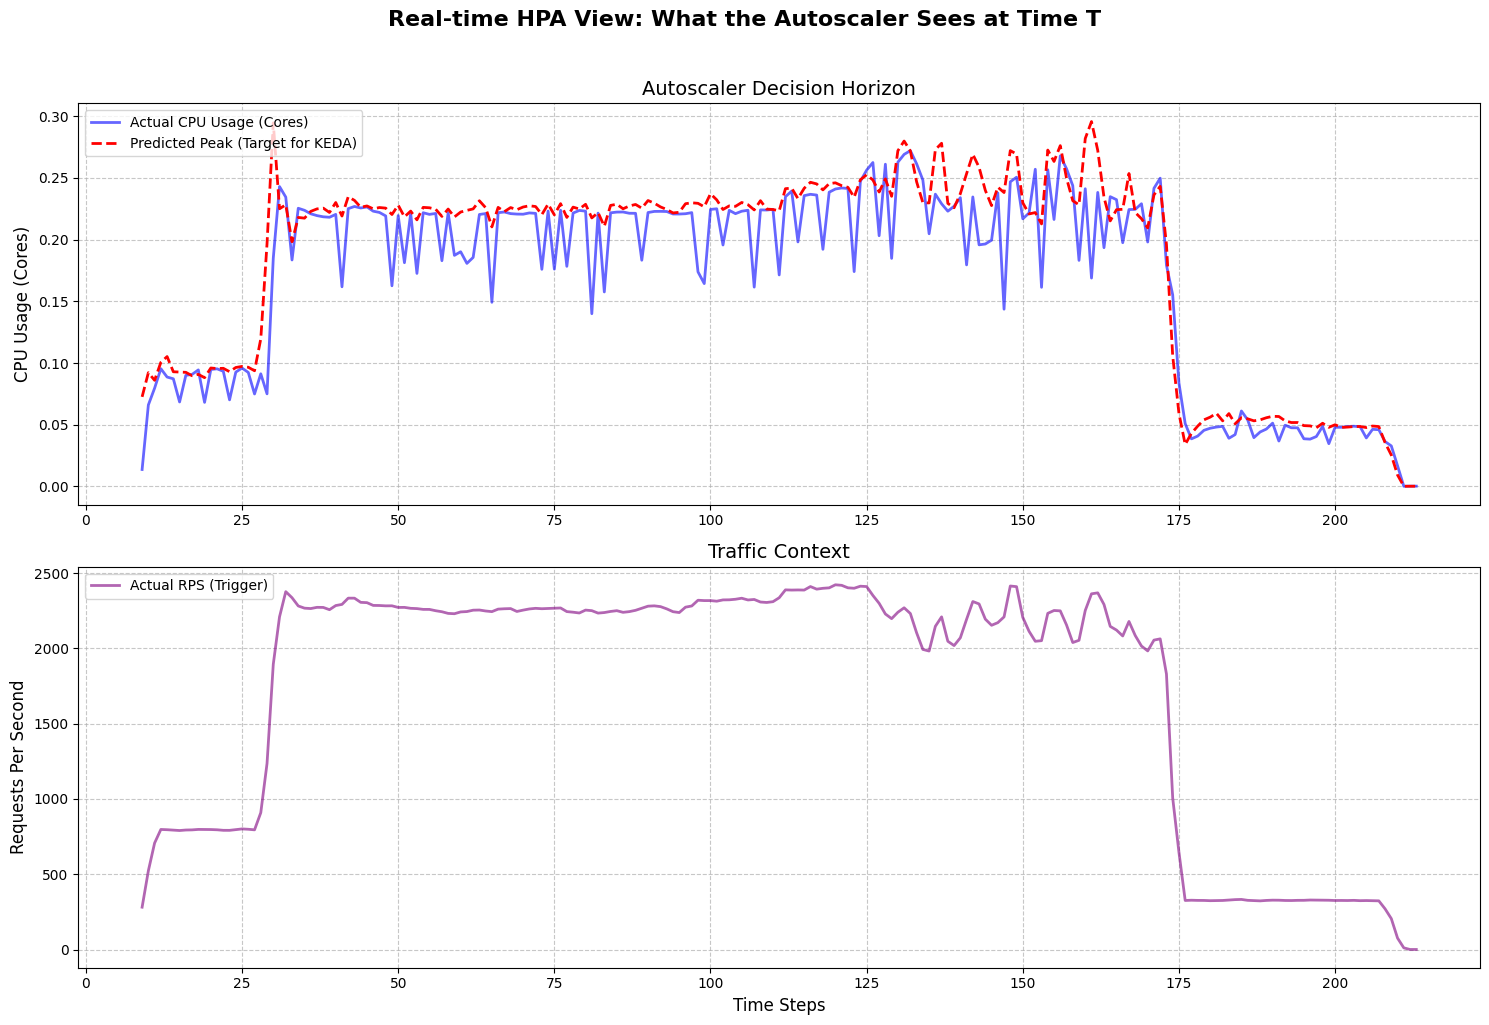

In [19]:
import numpy as np
import pandas as pd
import pickle 
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ==========================================
# 1. ЗАВАНТАЖЕННЯ АРТЕФАКТІВ
# ==========================================
print("🔄 Завантаження бойової моделі та скейлерів...")
model = load_model("production_k8s_autoscaler_sniper.keras")

with open("production_scaler_X.pkl", "rb") as f:
    scaler_X = pickle.load(f)
with open("production_scaler_y.pkl", "rb") as f:
    scaler_y = pickle.load(f)

df_ext = pd.read_csv("./clean_data/training_data.csv")
features = ['cpu', 'ram', 'rps']
raw_data = df_ext[features].values

WINDOW_SIZE = 10
epsilon = 1e-6

# Масиви для правильного, синхронного графіка
time_steps = []
actual_cpu_at_T = []
predicted_peak_at_T = []
actual_rps_at_T = []

print("🚀 Симуляція реального часу (Синхронний Інференс)...")
# Йдемо до самого кінця масиву
for i in range(WINDOW_SIZE, len(raw_data)):
    
    # Історія до поточного моменту Т (включно з ним)
    history_window = raw_data[i - WINDOW_SIZE : i] 
    current_time_idx = i - 1
    
    current_absolute_cpu = history_window[-1][0]
    
    # Рахуємо Log Returns
    log_returns_window = np.log((history_window[1:] + epsilon) / (history_window[:-1] + epsilon))
    
    X_scaled = scaler_X.transform(log_returns_window)
    X_input = np.expand_dims(X_scaled, axis=0)
    
    # Прогноз (що буде в наступні 4 кроки)
    pred_scaled = model.predict(X_input, verbose=0)
    pred_log = scaler_y.inverse_transform(pred_scaled)[0][0]
    pred_ratio = np.exp(pred_log)
    pred_absolute_cpu = current_absolute_cpu * pred_ratio
    
    # 💡 ЗБЕРІГАЄМО ВСЕ СИНХРОННО ДЛЯ ЧАСУ "T"
    time_steps.append(current_time_idx)
    actual_cpu_at_T.append(current_absolute_cpu)
    predicted_peak_at_T.append(pred_absolute_cpu)
    actual_rps_at_T.append(raw_data[current_time_idx][2])

# ==========================================
# 2. ГЕНЕРАЦІЯ СИНХРОННОГО ГРАФІКА
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('Real-time HPA View: What the Autoscaler Sees at Time T', fontsize=16, fontweight='bold', y=1.02)

# Верхній графік: Реальність vs Те, що бачить KEDA
axes[0].plot(time_steps, actual_cpu_at_T, label='Actual CPU Usage (Cores)', color='blue', alpha=0.6, linewidth=2)
axes[0].plot(time_steps, predicted_peak_at_T, label='Predicted Peak (Target for KEDA)', color='red', linestyle='dashed', linewidth=2)
axes[0].set_title('Autoscaler Decision Horizon', fontsize=14)
axes[0].set_ylabel('CPU Usage (Cores)', fontsize=12)
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Нижня графік: Трафік
axes[1].plot(time_steps, actual_rps_at_T, label='Actual RPS (Trigger)', color='purple', alpha=0.6, linewidth=2)
axes[1].set_title('Traffic Context', fontsize=14)
axes[1].set_ylabel('Requests Per Second', fontsize=12)
axes[1].set_xlabel('Time Steps', fontsize=12)
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()